import tensorflow as tf

# This line automatically downloads + loads dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

In [2]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import pandas as pd
import math

In [4]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

In [5]:
train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

100%|██████████| 170M/170M [00:14<00:00, 11.8MB/s]


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [7]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features, gate_init=2.0):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        self.bias = nn.Parameter(torch.empty(out_features))
        self.gate_scores = nn.Parameter(torch.full((out_features, in_features), gate_init))

        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))

        fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
        bound = 1 / math.sqrt(fan_in)
        nn.init.uniform_(self.bias, -bound, bound)

    def gates(self):
        return torch.sigmoid(self.gate_scores)

    def forward(self, x):
        pruned_weights = self.weight * self.gates()
        return F.linear(x, pruned_weights, self.bias)

In [8]:
class SelfPruningCNN(nn.Module):
    def __init__(self, gate_init=2.0):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.3)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            PrunableLinear(256 * 4 * 4, 512, gate_init=gate_init),
            nn.ReLU(),
            nn.Dropout(0.4),
            PrunableLinear(512, 10, gate_init=gate_init)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [9]:
def sparsity_loss(model):
    reg = 0.0
    count = 0
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = module.gates()
            reg += gates.sum()
            count += gates.numel()
    return reg / count

In [10]:
def evaluate_model(model, data_loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return 100.0 * correct / total

In [11]:
def train_model(model, train_loader, test_loader, lambda_sparse=1e-4, epochs=60, warmup_epochs=15, lr=1e-3):
    model = model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    best_acc = 0.0
    best_state = None
    history = {
        "train_loss": [],
        "test_acc": [],
        "lambda": []
    }

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        if epoch < warmup_epochs:
            current_lambda = 0.0
        else:
            progress = (epoch - warmup_epochs + 1) / (epochs - warmup_epochs)
            current_lambda = lambda_sparse * progress

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            cls_loss = criterion(outputs, labels)
            sp_loss = sparsity_loss(model)
            total_loss = cls_loss + current_lambda * sp_loss

            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

            running_loss += total_loss.item()

        scheduler.step()

        avg_train_loss = running_loss / len(train_loader)
        test_acc = evaluate_model(model, test_loader)

        history["train_loss"].append(avg_train_loss)
        history["test_acc"].append(test_acc)
        history["lambda"].append(current_lambda)

        if test_acc > best_acc:
            best_acc = test_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"LambdaNow: {current_lambda:.6f} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Test Acc: {test_acc:.2f}% | "
            f"Best Acc: {best_acc:.2f}%"
        )

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, best_acc, history

In [12]:
def calculate_sparsity(model, threshold=1e-2):
    total = 0
    pruned = 0
    gate_sum = 0.0

    with torch.no_grad():
        for module in model.modules():
            if isinstance(module, PrunableLinear):
                gates = module.gates()
                total += gates.numel()
                pruned += (gates < threshold).sum().item()
                gate_sum += gates.sum().item()

    sparsity = 100.0 * pruned / total
    avg_gate = gate_sum / total
    return sparsity, avg_gate

In [13]:
def collect_all_gates(model):
    all_gates = []

    with torch.no_grad():
        for module in model.modules():
            if isinstance(module, PrunableLinear):
                all_gates.append(module.gates().detach().cpu().view(-1))

    return torch.cat(all_gates).numpy()

In [14]:
lambda_values = [1e-5]

In [15]:
results = []
trained_models = {}
all_histories = {}

for lam in lambda_values:
    print(f"\n{'='*20} Training with lambda = {lam} {'='*20}")

    model = SelfPruningCNN()

    model, best_acc, history = train_model(
        model,
        train_loader,
        test_loader,
        lambda_sparse=lam,
        epochs=60,
        warmup_epochs=15,
        lr=1e-3
    )

    final_acc = evaluate_model(model, test_loader)
    sparsity, avg_gate = calculate_sparsity(model)

    results.append({
        "Lambda": lam,
        "Best/Test Accuracy": round(final_acc, 2),
        "Sparsity Level (%)": round(sparsity, 2),
        "Average Gate Value": round(avg_gate, 4)
    })

    trained_models[lam] = model
    all_histories[lam] = history

    print(f"\nLambda: {lam}")
    print(f"Final Accuracy: {final_acc:.2f}%")
    print(f"Sparsity: {sparsity:.2f}%")
    print(f"Average Gate Value: {avg_gate:.4f}")


==================== Training with lambda = 1e-05 ====================
Epoch 01/60 | LambdaNow: 0.000000 | Train Loss: 1.8292 | Test Acc: 53.87% | Best Acc: 53.87%
Epoch 02/60 | LambdaNow: 0.000000 | Train Loss: 1.5045 | Test Acc: 60.45% | Best Acc: 60.45%
Epoch 03/60 | LambdaNow: 0.000000 | Train Loss: 1.3666 | Test Acc: 66.06% | Best Acc: 66.06%
Epoch 04/60 | LambdaNow: 0.000000 | Train Loss: 1.2850 | Test Acc: 72.79% | Best Acc: 72.79%
Epoch 05/60 | LambdaNow: 0.000000 | Train Loss: 1.2325 | Test Acc: 73.27% | Best Acc: 73.27%
Epoch 06/60 | LambdaNow: 0.000000 | Train Loss: 1.1822 | Test Acc: 78.12% | Best Acc: 78.12%
Epoch 07/60 | LambdaNow: 0.000000 | Train Loss: 1.1445 | Test Acc: 78.34% | Best Acc: 78.34%
Epoch 08/60 | LambdaNow: 0.000000 | Train Loss: 1.1178 | Test Acc: 77.39% | Best Acc: 78.34%
Epoch 09/60 | LambdaNow: 0.000000 | Train Loss: 1.0895 | Test Acc: 81.19% | Best Acc: 81.19%
Epoch 10/60 | LambdaNow: 0.000000 | Train Loss: 1.0670 | Test Acc: 82.83% | Best Acc: 82.83

In [16]:
df = pd.DataFrame(results)
df

,Lambda,Best/Test Accuracy,Sparsity Level (%),Average Gate Value
0,0.00001,90.56,0.0,0.8788


In [17]:
best_lambda = df.sort_values("Best/Test Accuracy", ascending=False).iloc[0]["Lambda"]
best_model = trained_models[best_lambda]

print("Best lambda:", best_lambda)
print(df.sort_values("Best/Test Accuracy", ascending=False))

Best lambda: 1e-05
    Lambda  Best/Test Accuracy  Sparsity Level (%)  Average Gate Value
0  0.00001               90.56                 0.0              0.8788


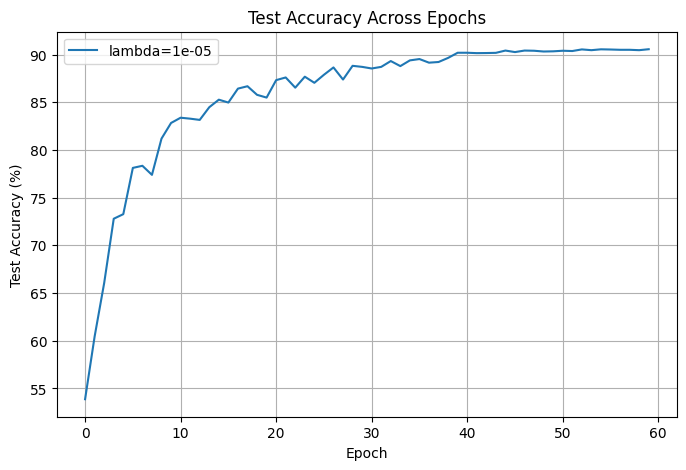

In [18]:
plt.figure(figsize=(8, 5))

for lam, history in all_histories.items():
    plt.plot(history["test_acc"], label=f"lambda={lam}")

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.title("Test Accuracy Across Epochs")
plt.legend()
plt.grid(True)
plt.show()

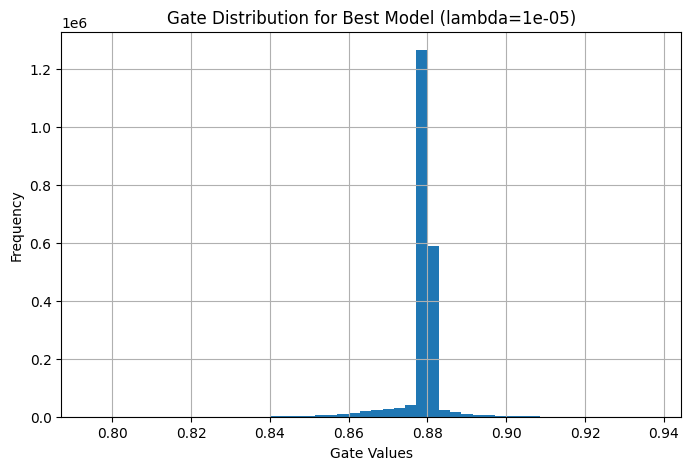

In [19]:
all_gates = collect_all_gates(best_model)

plt.figure(figsize=(8, 5))
plt.hist(all_gates, bins=50)
plt.xlabel("Gate Values")
plt.ylabel("Frequency")
plt.title(f"Gate Distribution for Best Model (lambda={best_lambda})")
plt.grid(True)
plt.show()

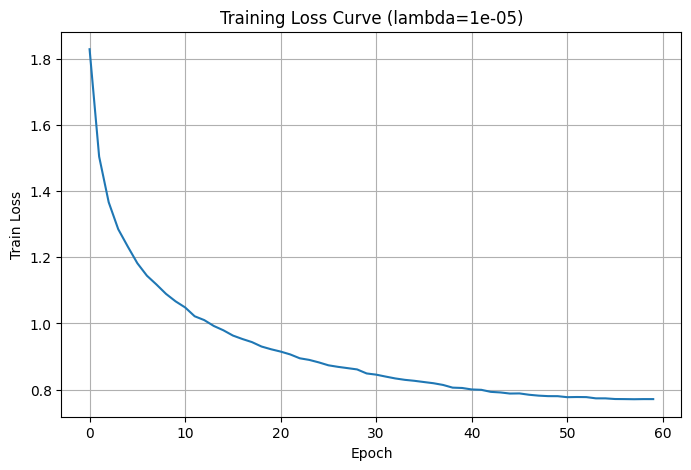

In [20]:
best_history = all_histories[best_lambda]

plt.figure(figsize=(8, 5))
plt.plot(best_history["train_loss"])
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title(f"Training Loss Curve (lambda={best_lambda})")
plt.grid(True)
plt.show()

In [21]:
print("\nFinal Summary")
print(df.sort_values("Best/Test Accuracy", ascending=False).to_string(index=False))


Final Summary
 Lambda  Best/Test Accuracy  Sparsity Level (%)  Average Gate Value
0.00001               90.56                 0.0              0.8788


In [22]:
selected_lambda = 1e-5
selected_model = model

print("Selected Lambda:", selected_lambda)

Selected Lambda: 1e-05


In [23]:
final_acc = evaluate_model(selected_model, test_loader)
sparsity, avg_gate = calculate_sparsity(selected_model)

print(f"Final Test Accuracy for lambda={selected_lambda}: {final_acc:.2f}%")
print(f"Sparsity Level for lambda={selected_lambda}: {sparsity:.2f}%")
print(f"Average Gate Value for lambda={selected_lambda}: {avg_gate:.4f}")

Final Test Accuracy for lambda=1e-05: 90.56%
Sparsity Level for lambda=1e-05: 0.00%
Average Gate Value for lambda=1e-05: 0.8788


In [24]:
import pandas as pd

selected_result_df = pd.DataFrame([{
    "Lambda": selected_lambda,
    "Test Accuracy (%)": round(final_acc, 2),
    "Sparsity Level (%)": round(sparsity, 2),
    "Average Gate Value": round(avg_gate, 4)
}])

selected_result_df

,Lambda,Test Accuracy (%),Sparsity Level (%),Average Gate Value
0,0.00001,90.56,0.0,0.8788


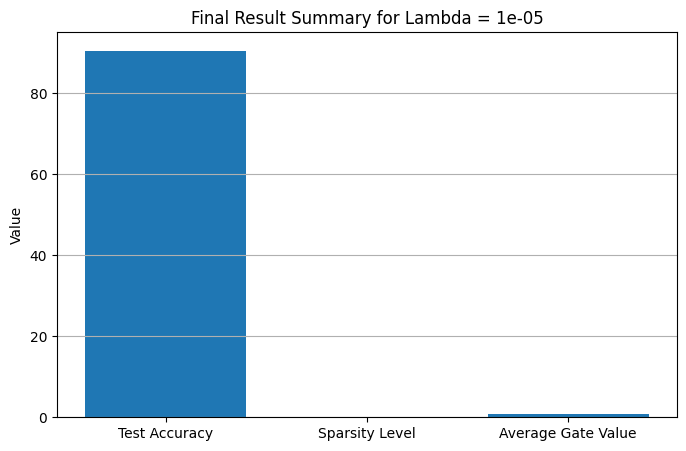

In [25]:
import matplotlib.pyplot as plt

metrics = ["Test Accuracy", "Sparsity Level", "Average Gate Value"]
values = [final_acc, sparsity, avg_gate]

plt.figure(figsize=(8, 5))
plt.bar(metrics, values)
plt.title(f"Final Result Summary for Lambda = {selected_lambda}")
plt.ylabel("Value")
plt.grid(axis='y')
plt.show()

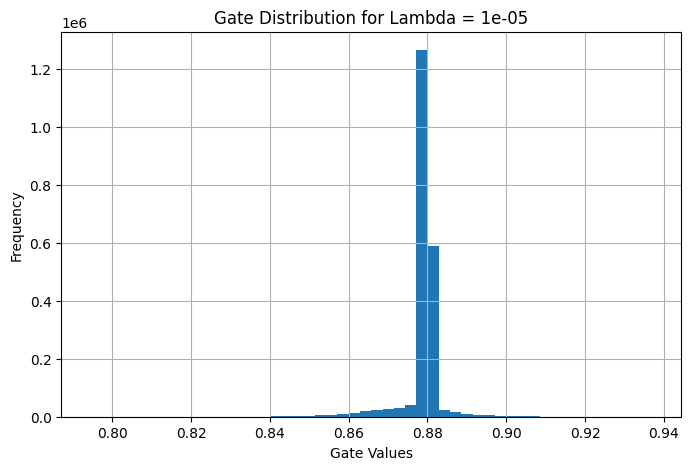

In [26]:
all_gates = collect_all_gates(selected_model)

plt.figure(figsize=(8, 5))
plt.hist(all_gates, bins=50)
plt.xlabel("Gate Values")
plt.ylabel("Frequency")
plt.title(f"Gate Distribution for Lambda = {selected_lambda}")
plt.grid(True)
plt.show()

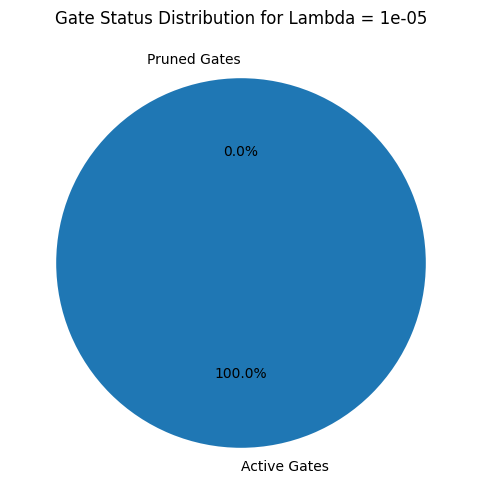

In [27]:
import numpy as np

threshold = 1e-2
pruned = np.sum(all_gates < threshold)
active = np.sum(all_gates >= threshold)

plt.figure(figsize=(6, 6))
plt.pie([active, pruned], labels=["Active Gates", "Pruned Gates"], autopct="%1.1f%%", startangle=90)
plt.title(f"Gate Status Distribution for Lambda = {selected_lambda}")
plt.show()

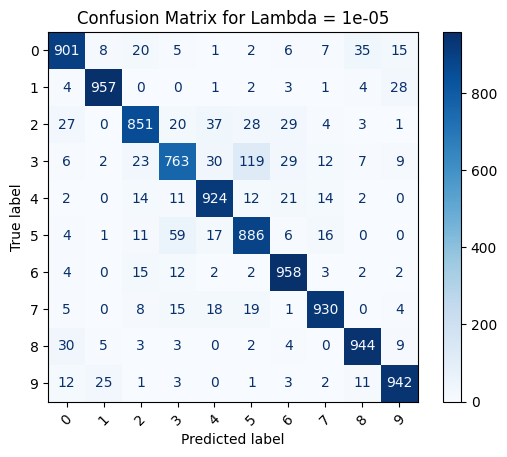

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import torch

y_true = []
y_pred = []

selected_model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = selected_model(images)
        preds = outputs.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title(f"Confusion Matrix for Lambda = {selected_lambda}")
plt.show()

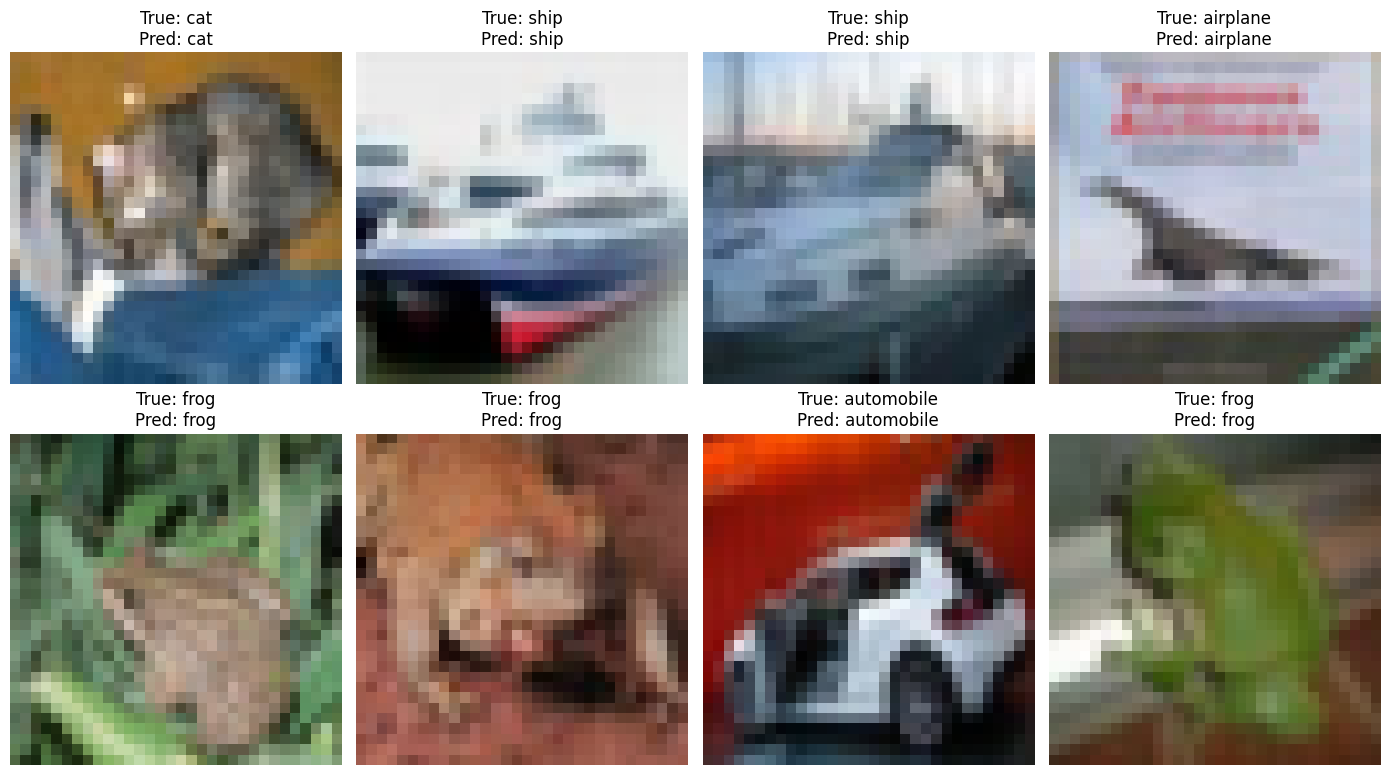

In [30]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

selected_model.eval()
with torch.no_grad():
    outputs = selected_model(images)
    preds = outputs.argmax(dim=1)

images = images.cpu()

mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

plt.figure(figsize=(14, 8))
for i in range(8):
    img = images[i] * std + mean
    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)

    plt.subplot(2, 4, i+1)
    plt.imshow(img)
    plt.title(f"True: {classes[labels[i].item()]}\nPred: {classes[preds[i].item()]}")
    plt.axis("off")

plt.tight_layout()
plt.show()